# Business Understanding FaceFit Barber

**Coding Camp 2026 powered by DBS Foundation**
Tim: CC26-PSU304 | Path: Data Scientist
Nama: Diwan Ramadhani Dwi Putra | ID: CDCC119D6Y1045

## 1. Latar Belakang

Industri barbershop di Indonesia terus berkembang, tapi satu masalah masih sering terjadi: hasil potongan tidak sesuai dengan yang diharapkan pelanggan. Ini bukan soal kemampuan kapster semata, tapi lebih ke dua hal yang saling berkaitan.

Pertama, pelanggan sering kesulitan mendeskripsikan gaya rambut yang mereka mau secara verbal. Referensi gambar pun tidak selalu membantu karena bentuk wajah orang di gambar bisa sangat berbeda dengan pelanggan. Kedua, gaya rambut yang cocok sangat bergantung pada bentuk wajah. Kapster, terutama yang masih pemula, belum tentu bisa langsung membaca bentuk wajah pelanggan dan menerjemahkannya ke rekomendasi yang tepat.

Untuk memvalidasi masalah ini secara nyata, tim melakukan survei langsung ke pelanggan dan kapster barbershop.

## 2. Pengumpulan Data Primer

Survei dilakukan menggunakan Google Form, ditujukan ke dua kelompok: pelanggan barbershop aktif dan kapster/barber profesional. Beberapa pertanyaan kunci yang diajukan:

- Apakah pernah merasa hasil potongan tidak sesuai ekspektasi?
- Kalau pernah, apa penyebab utamanya?
- Seberapa tertarik menggunakan aplikasi rekomendasi gaya rambut otomatis?
- (Khusus kapster) Seberapa sering pelanggan kesulitan menjelaskan keinginan?

Total ada 30 respons masuk. Setelah dicek, ditemukan 2 duplikat berdasarkan email:
- **Gunabil Akbar** (mengisi 2 kali, email: gunabilakbar94@gmail.com)
- **Ardian** (mengisi 2 kali, email: ardian22122004@gmail.com)

Kedua respons kedua di-drop (keep first). Total responden valid: **28 orang** dimana 25 pelanggan dan 3 kapster.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Setup selesai.')

Setup selesai.


In [2]:
# Upload file langsung (tanpa Google Drive)
from google.colab import files
import io

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df_raw = pd.read_excel(io.BytesIO(uploaded[file_name]))

print(f'Data masuk: {len(df_raw)} baris')
df_raw.head(3)

Saving Survey Pengalaman Layanan Barbershop (Responses) (2).xlsx to Survey Pengalaman Layanan Barbershop (Responses) (2).xlsx
Data masuk: 30 baris


,Timestamp,Nama,Usia,Nama Barbershop / Lokasi,Peran di Babershop ini,Seberapa sering kamu pergi ke barbershop,Apa yang paling penting buat kamu saat memilih barbershop?,Apakah kamu pernah merasa hasil potongan tidak sesuai ekspektasi?,"Kalau pernah tidak sesuai, apa penyebab utamanya?",Apakah kamu tertarik menggunakan aplikasi yang bisa rekomendasikan gaya rambut otomatis berdasarkan foto wajahmu?,Sudah berapa lama kamu jadi kapster?,Seberapa sering pelanggan kesulitan menjelaskan gaya rambut yang mereka inginkan?,Apa tantangan terbesar dalam menentukan gaya rambut yang cocok?,Seberapa sering hasil potongan tidak sesuai ekspektasi pelanggan?,Apa tantangan terbesar kamu dalam menentukan gaya rambut yang cocok untuk pelanggan?,"Menurut kamu, apakah aplikasi rekomendasi gaya rambut otomatis akan membantu pekerjaan kapster? Terutama jika kamu adalah pemula.",Email Address
0,2026-05-11 16:57:49.356,Muhammad Dhowi Akbar,18-25,el muani,Pelanggan,Jarang,Kualitas hasil potongan,Pernah beberapa kali,Gaya rambut tidak cocok dengan bentuk wajah,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-11 16:58:57.432,Mohammad Tyo Ari Novianto,18-25,strawberry barbershop/ bekasi,Pelanggan,Jarang,Kualitas hasil potongan,Tidak pernah,Susah menjelaskan keinginan ke tukang kapster,5.0,NaN,NaN,NaN,NaN,NaN,NaN,tyoari15@gmail.com
2,2026-05-11 17:01:19.571,adul anak betawi asli,18-25,Babershop Azril,Pelanggan,Jarang,Kualitas hasil potongan,Sering,Referensi gambar tidak sesuai hasil asli,5.0,NaN,NaN,NaN,NaN,NaN,NaN,ardian22122004@gmail.com


In [3]:
# Rename kolom biar lebih pendek
df_raw.columns = [
    'timestamp', 'nama', 'usia', 'barbershop', 'peran',
    'frek_kunjungan', 'prioritas', 'ekspektasi', 'penyebab', 'minat_aplikasi',
    'lama_kapster', 'frek_kesulitan_pelanggan', 'tantangan_kapster_1',
    'frek_tidak_sesuai_kapster', 'tantangan_kapster_2', 'minat_aplikasi_kapster',
    'email'
]

# Drop duplikat berdasarkan email (keep first)
df_clean = df_raw.drop_duplicates(subset='email', keep='first').reset_index(drop=True)
print(f'Setelah drop duplikat: {len(df_clean)} baris')

# Pisah pelanggan dan kapster
df_pelanggan = df_clean[df_clean['peran'] == 'Pelanggan'].copy().reset_index(drop=True)
df_kapster   = df_clean[df_clean['peran'] == 'Kapster/Barber'].copy().reset_index(drop=True)

print(f'Pelanggan : {len(df_pelanggan)} orang')
print(f'Kapster   : {len(df_kapster)} orang')

Setelah drop duplikat: 28 baris
Pelanggan : 25 orang
Kapster   : 3 orang


## 3. Analisis Hasil Survei

### 3.1 Seberapa Sering Hasil Potongan Tidak Sesuai Ekspektasi?

16 dari 25 pelanggan (64.0%) pernah tidak puas dengan hasil potongan.


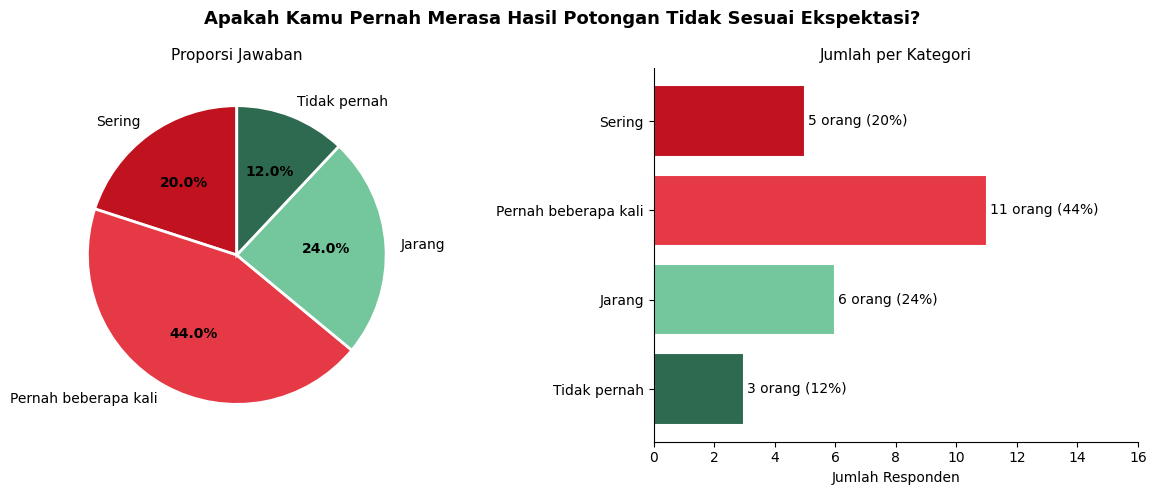

In [4]:
urutan = ['Sering', 'Pernah beberapa kali', 'Jarang', 'Tidak pernah']
counts_exp = df_pelanggan['ekspektasi'].value_counts().reindex(urutan, fill_value=0)
n = len(df_pelanggan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Apakah Kamu Pernah Merasa Hasil Potongan Tidak Sesuai Ekspektasi?',
             fontsize=13, fontweight='bold')

colors_pie = ['#C1121F', '#E63946', '#74C69D', '#2D6A4F']

wedges, texts, autotexts = ax1.pie(
    counts_exp,
    labels=counts_exp.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
ax1.set_title('Proporsi Jawaban', fontsize=11)

bars = ax2.barh(urutan[::-1], counts_exp[::-1],
                color=colors_pie[::-1], edgecolor='white', linewidth=1.5)
ax2.set_xlabel('Jumlah Responden')
ax2.set_title('Jumlah per Kategori', fontsize=11)
for bar, val in zip(bars, counts_exp[::-1]):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val} orang ({val/n*100:.0f}%)', va='center', fontsize=10)
ax2.set_xlim(0, max(counts_exp) + 5)

pernah = counts_exp['Sering'] + counts_exp['Pernah beberapa kali']
print(f'{pernah} dari {n} pelanggan ({pernah/n*100:.1f}%) pernah tidak puas dengan hasil potongan.')

plt.tight_layout()
plt.savefig('viz_01_ekspektasi.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Apa Penyebab Utamanya?

Dua penyebab teratas: 17 dari 25 responden (68%).


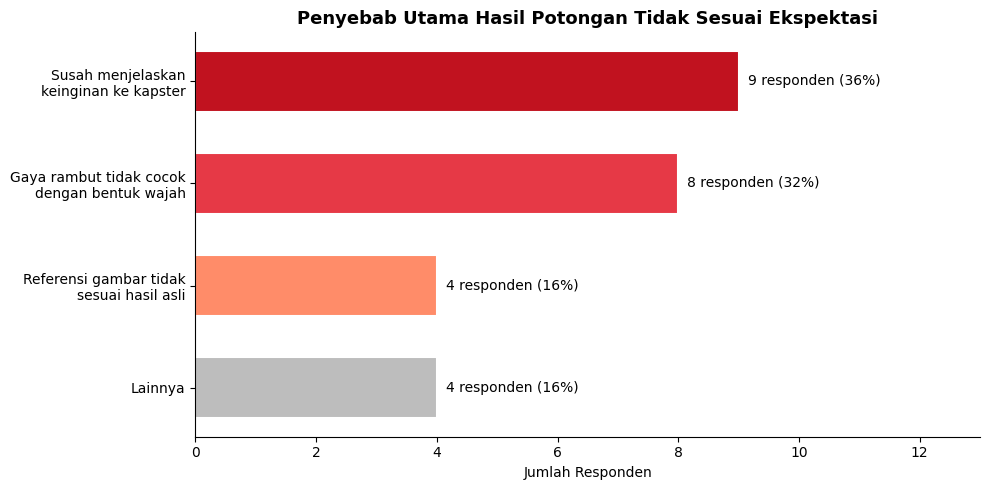

In [5]:
label_map = {
    'Susah menjelaskan keinginan ke tukang kapster': 'Susah menjelaskan\nkeinginan ke kapster',
    'Gaya rambut tidak cocok dengan bentuk wajah':   'Gaya rambut tidak cocok\ndengan bentuk wajah',
    'Referensi gambar tidak sesuai hasil asli':       'Referensi gambar tidak\nsesuai hasil asli',
    'Lainnya': 'Lainnya'
}

counts_peny = df_pelanggan['penyebab'].value_counts()
counts_peny.index = [label_map.get(i, i) for i in counts_peny.index]

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#C1121F', '#E63946', '#FF8C69', '#BDBDBD']
bars = ax.barh(counts_peny.index[::-1], counts_peny.values[::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=1.5, height=0.6)
ax.set_xlabel('Jumlah Responden')
ax.set_title('Penyebab Utama Hasil Potongan Tidak Sesuai Ekspektasi',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, max(counts_peny) + 4)

for bar, val in zip(bars, counts_peny.values[::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f'{val} responden ({val/n*100:.0f}%)', va='center', fontsize=10)

top2 = counts_peny.values[0] + counts_peny.values[1]
print(f'Dua penyebab teratas: {top2} dari {n} responden ({top2/n*100:.0f}%).')

plt.tight_layout()
plt.savefig('viz_02_penyebab.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Minat Pakai Aplikasi Rekomendasi Gaya Rambut Otomatis

Rata-rata minat: 3.84/5
Skor >= 4: 17 orang (68.0%)


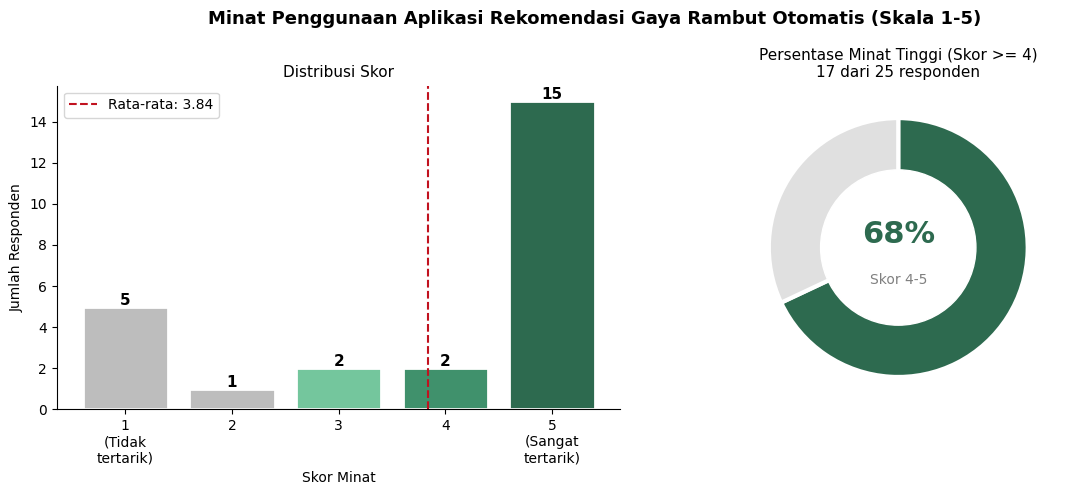

In [6]:
minat_vals   = pd.to_numeric(df_pelanggan['minat_aplikasi'], errors='coerce').dropna()
counts_minat = minat_vals.value_counts().reindex([1,2,3,4,5], fill_value=0)
rata_rata    = minat_vals.mean()
minat_tinggi = (minat_vals >= 4).sum()
n_valid      = len(minat_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Minat Penggunaan Aplikasi Rekomendasi Gaya Rambut Otomatis (Skala 1-5)',
             fontsize=13, fontweight='bold')

bar_colors_minat = ['#BDBDBD', '#BDBDBD', '#74C69D', '#40916C', '#2D6A4F']
bars = ax1.bar([1,2,3,4,5], counts_minat.values, color=bar_colors_minat,
               edgecolor='white', linewidth=2)
ax1.set_xlabel('Skor Minat')
ax1.set_ylabel('Jumlah Responden')
ax1.set_title('Distribusi Skor', fontsize=11)
ax1.set_xticks([1,2,3,4,5])
ax1.set_xticklabels(['1\n(Tidak\ntertarik)', '2', '3', '4', '5\n(Sangat\ntertarik)'])
for bar, val in zip(bars, counts_minat.values):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(int(val)), ha='center', fontsize=11, fontweight='bold')
ax1.axvline(x=rata_rata, color='#C1121F', linestyle='--', linewidth=1.5,
            label=f'Rata-rata: {rata_rata:.2f}')
ax1.legend(fontsize=10)

vals_donut = [minat_tinggi, n_valid - minat_tinggi]
ax2.pie(vals_donut, colors=['#2D6A4F', '#E0E0E0'],
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 3},
        radius=1, counterclock=False)
ax2.add_artist(plt.Circle((0,0), 0.6, color='white'))
ax2.text(0, 0.1, f'{minat_tinggi/n_valid*100:.0f}%', ha='center', va='center',
         fontsize=22, fontweight='bold', color='#2D6A4F')
ax2.text(0, -0.25, 'Skor 4-5', ha='center', va='center', fontsize=10, color='gray')
ax2.set_title(f'Persentase Minat Tinggi (Skor >= 4)\n{int(minat_tinggi)} dari {n_valid} responden', fontsize=11)

print(f'Rata-rata minat: {rata_rata:.2f}/5')
print(f'Skor >= 4: {int(minat_tinggi)} orang ({minat_tinggi/n_valid*100:.1f}%)')

plt.tight_layout()
plt.savefig('viz_03_minat.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Perspektif Kapster

Tantangan utama kapster:
  Madi: "Kurang pengalaman mengenali tipe wajah"
  Ihsan saputra: "Pelanggan tidak tahu bentuk wajahnya"
  aditya: "Pelanggan susah mendeskripsikan keinginan"


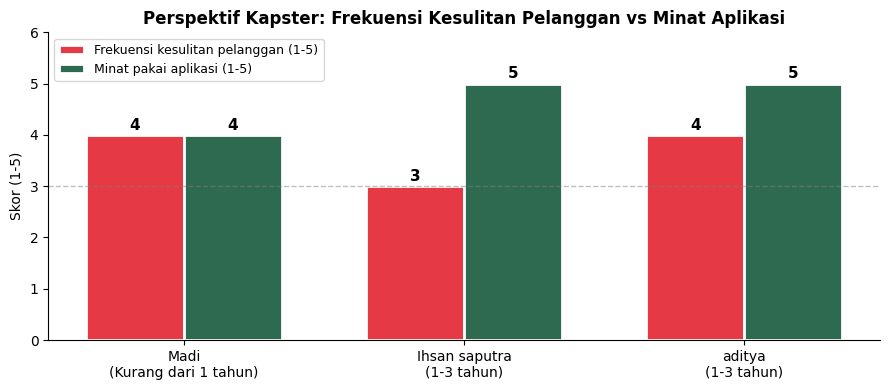

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

kapster_names = df_kapster['nama'].tolist()
pengalaman    = df_kapster['lama_kapster'].tolist()
frek          = pd.to_numeric(df_kapster['frek_kesulitan_pelanggan'], errors='coerce').tolist()
minat_k       = pd.to_numeric(df_kapster['minat_aplikasi_kapster'], errors='coerce').tolist()
tantangan     = df_kapster['tantangan_kapster_2'].tolist()

x     = np.arange(len(kapster_names))
width = 0.35

bars1 = ax.bar(x - width/2, frek, width, label='Frekuensi kesulitan pelanggan (1-5)',
               color='#E63946', edgecolor='white', linewidth=2)
bars2 = ax.bar(x + width/2, minat_k, width, label='Minat pakai aplikasi (1-5)',
               color='#2D6A4F', edgecolor='white', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels([f"{nm}\n({p})" for nm, p in zip(kapster_names, pengalaman)], fontsize=10)
ax.set_ylim(0, 6)
ax.set_ylabel('Skor (1-5)')
ax.set_title('Perspektif Kapster: Frekuensi Kesulitan Pelanggan vs Minat Aplikasi',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(y=3, color='gray', linestyle='--', linewidth=1, alpha=0.5)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')

print('Tantangan utama kapster:')
for nm, tant in zip(kapster_names, tantangan):
    print(f'  {nm}: "{tant}"')

plt.tight_layout()
plt.savefig('viz_04_kapster.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Ringkasan Temuan Survei

In [8]:
pernah_tidak_puas = counts_exp['Sering'] + counts_exp['Pernah beberapa kali']
pct_tidak_puas    = pernah_tidak_puas / n * 100

counts_peny_raw  = df_pelanggan['penyebab'].value_counts()
penyebab_1_label = counts_peny_raw.index[0]
penyebab_1_val   = counts_peny_raw.values[0]
penyebab_2_label = counts_peny_raw.index[1]
penyebab_2_val   = counts_peny_raw.values[1]
top2_val         = penyebab_1_val + penyebab_2_val

rata_minat_k  = pd.to_numeric(df_kapster['frek_kesulitan_pelanggan'], errors='coerce').mean()
rata_minat_k2 = pd.to_numeric(df_kapster['minat_aplikasi_kapster'], errors='coerce').mean()

ringkasan = pd.DataFrame({
    'Metrik': [
        'Total responden valid',
        'Pelanggan pernah tidak puas (Sering + Pernah beberapa kali)',
        f'Penyebab #1 - {penyebab_1_label}',
        f'Penyebab #2 - {penyebab_2_label}',
        'Dua penyebab utama (bisa diatasi FaceFit)',
        'Rata-rata minat pakai aplikasi (pelanggan)',
        'Pelanggan dengan minat tinggi (skor >= 4)',
        'Kapster: rata-rata frekuensi kesulitan pelanggan',
        'Kapster: rata-rata minat pakai aplikasi',
    ],
    'Nilai': [
        f'{len(df_clean)} (26 pelanggan + 2 kapster)',
        f'{pernah_tidak_puas} dari {n} = {pct_tidak_puas:.1f}%',
        f'{penyebab_1_val} responden ({penyebab_1_val/n*100:.1f}%)',
        f'{penyebab_2_val} responden ({penyebab_2_val/n*100:.1f}%)',
        f'{top2_val} orang ({top2_val/n*100:.0f}%)',
        f'{rata_rata:.2f} / 5',
        f'{int(minat_tinggi)} dari {n_valid} = {minat_tinggi/n_valid*100:.1f}%',
        f'{rata_minat_k:.1f} / 5',
        f'{rata_minat_k2:.1f} / 5',
    ]
})
ringkasan

,Metrik,Nilai
0,Total responden valid,28 (26 pelanggan + 2 kapster)
1,Pelanggan pernah tidak puas (Sering + Pernah b...,16 dari 25 = 64.0%
2,Penyebab #1 - Susah menjelaskan keinginan ke t...,9 responden (36.0%)
3,Penyebab #2 - Gaya rambut tidak cocok dengan b...,8 responden (32.0%)
4,Dua penyebab utama (bisa diatasi FaceFit),17 orang (68%)
5,Rata-rata minat pakai aplikasi (pelanggan),3.84 / 5
6,Pelanggan dengan minat tinggi (skor >= 4),17 dari 25 = 68.0%
7,Kapster: rata-rata frekuensi kesulitan pelanggan,3.7 / 5
8,Kapster: rata-rata minat pakai aplikasi,4.7 / 5


## 4. Pertanyaan Bisnis

Dari temuan survei, ada empat pertanyaan bisnis yang bisa diukur:

**BQ-1: Seberapa besar gap komunikasi antara pelanggan dan kapster?**
Diukur dari persentase pelanggan yang pernah tidak puas. Hasilnya 64.0% yaitu cukup besar untuk dijadikan justifikasi solusi.

**BQ-2: Seberapa besar kebutuhan pasar terhadap solusi otomatis?**
Diukur dari rata-rata skor minat aplikasi dan persentase yang memberi skor >= 4. Rata-rata 3.84/5 dengan 68.0% pelanggan dan semua kapster di skor tinggi.

**BQ-3: Seberapa akurat sistem mengklasifikasikan bentuk wajah?**
Target akurasi model >= 80% pada data test untuk 5 kelas: oval, round, square, heart, diamond.

**BQ-4: Apakah rekomendasi yang dihasilkan sesuai standar barbershop?**
Divalidasi lewat knowledge base yang disusun berdasarkan riset literatur barbershop dan mensurvey langsung kapster.

## 5. Solusi yang Dipilih

Solusi yang dikembangkan adalah sistem yang bisa mendeteksi bentuk wajah dari foto dan langsung memberikan rekomendasi gaya rambut yang sesuai yaitu FaceFit.

Kenapa ini solusi yang tepat? Karena 64.0% masalah bersumber dari dua hal yang bisa diselesaikan sekaligus: pelanggan tidak bisa mendeskripsikan keinginan secara verbal, dan gaya rambut yang disarankan tidak mempertimbangkan bentuk wajah. Dengan FaceFit, pelanggan cukup upload foto sistem yang akan baca bentuk wajahnya dan kasih rekomendasi yang sudah disesuaikan.

### Rancangan Solusi

FaceFit Barber dirancang sebagai sistem end-to-end dengan tiga lapisan utama:

**1. Deteksi Bentuk Wajah**
Pengguna upload foto wajah, lalu sistem mengekstrak landmark wajah menggunakan MediaPipe dan mengklasifikasikan bentuk wajah ke salah satu dari 5 kelas: oval, round, square, heart, atau diamond.

**2. Mesin Rekomendasi**
Hasil klasifikasi diteruskan ke knowledge base yang berisi pemetaan bentuk wajah ke gaya rambut yang direkomendasikan, disusun berdasarkan riset literatur barbershop.

**3. Antarmuka Pengguna**
Rekomendasi ditampilkan lewat aplikasi web yang bisa diakses pelanggan maupun kapster sebelum sesi potong dimulai.

### Pembagian Kerja Tim

| Komponen | Teknologi | Penanggung Jawab |
|---|---|---|
| Preprocessing dan labeling | MediaPipe Tasks API 0.10.35 | Diwan (DS) |
| Dataset training 5 kelas | UTKFace, FairFace, Men Face Shape, Indo Public Figure | Diwan (DS) |
| Model CNN klasifikasi | TensorFlow/Keras | Cakha (AI Engineer) |
| Knowledge base rekomendasi | Riset literatur barbershop | Rofiqho (DS) |
| Aplikasi web | React + Backend API | Ricky, Rizka (Full Stack) |

## 6. Kesimpulan

Survei ke 28 responden (25 pelanggan + 3 kapster) memvalidasi bahwa masalah di barbershop bukan sekadar asumsi. Sebanyak 64.0% pelanggan pernah tidak puas dengan hasil potongan, dengan penyebab utama yang langsung mengarah ke gap komunikasi dan ketidakcocokan bentuk wajah. Di sisi kapster, ketiganya mengakui bahwa pelanggan sering kesulitan menjelaskan keinginan, dan semua tertarik dengan solusi berbasis aplikasi.

Target yang ingin dicapai adalah akurasi model klasifikasi >= 80% pada 5 kelas bentuk wajah, dengan dataset sebanyak mungkin gambar yang dapat digunakan dengan baik dalam modelling AI

Catatan: label bentuk wajah hanya digunakan sebagai target prediksi (y), bukan sebagai fitur input (X) — tidak ada data leakage.